In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

MY_DRIVE = Path("/content/drive/MyDrive")

matches = []

for p in MY_DRIVE.rglob("Waste_Classification"):
    if p.is_dir():
        matches.append(p)

print("Waste_Classification folders found:")

for p in matches:
    print(p)

Waste_Classification folders found:
/content/drive/MyDrive/Waste_Classification


In [3]:
for p in matches:
    print("\n" + "=" * 70)
    print("FOLDER:", p)
    print("=" * 70)

    try:
        for item in sorted(p.iterdir()):
            print(item.name)
    except Exception as e:
        print("Could not read:", e)


FOLDER: /content/drive/MyDrive/Waste_Classification
.git
.gitignore
README.md
audit_reports
code
data
notebooks
results


In [4]:
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

STAGE1 = PROJECT / "data" / "processed" / "stage1_cleaning"

print("=" * 70)
print("STAGE 1 DATASET CHECK")
print("=" * 70)

print("Project exists:", PROJECT.exists())
print("Stage 1 exists:", STAGE1.exists())
print("Stage 1 path:", STAGE1)

if STAGE1.exists():
    print("\nStage 1 contents:")
    for item in sorted(STAGE1.iterdir()):
        print(item.name)

STAGE 1 DATASET CHECK
Project exists: True
Stage 1 exists: True
Stage 1 path: /content/drive/MyDrive/Waste_Classification/data/processed/stage1_cleaning

Stage 1 contents:
Hazardous
Non-Recyclable
Organic
Recyclable


In [5]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
    ".gif",
    ".tif",
    ".tiff"
}

stage1_files = sorted([
    p for p in STAGE1.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("=" * 70)
print("STAGE 1 IMAGE COUNT")
print("=" * 70)

print("Total images:", len(stage1_files))

STAGE 1 IMAGE COUNT
Total images: 2935


In [8]:
!pip -q install ImageHash

In [9]:
import os
import shutil
import hashlib
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image, ImageFile

import matplotlib.pyplot as plt
import imagehash

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

STAGE1 = PROJECT / "data" / "processed" / "stage1_cleaning"

STAGE2 = PROJECT / "data" / "processed" / "stage2_deduplicated"

RESULTS = PROJECT / "results"

OUTPUT_DIR = RESULTS / "outputs"

EDA_DIR = RESULTS / "eda_visualizations"

REVIEW_DIR = RESULTS / "member2_visual_review"

STAGE2.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders ready.")
print("Stage 2:", STAGE2)
print("Reports:", OUTPUT_DIR)
print("EDA:", EDA_DIR)
print("Review:", REVIEW_DIR)

Output folders ready.
Stage 2: /content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated
Reports: /content/drive/MyDrive/Waste_Classification/results/outputs
EDA: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations
Review: /content/drive/MyDrive/Waste_Classification/results/member2_visual_review


In [11]:
def calculate_sha256(file_path):
    sha = hashlib.sha256()

    with open(file_path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha.update(chunk)

    return sha.hexdigest()

print("SHA-256 function ready.")

SHA-256 function ready.


In [12]:
hash_records = []

print("=" * 70)
print("CALCULATING SHA-256 HASHES")
print("=" * 70)

for index, file_path in enumerate(stage1_files):

    relative_path = file_path.relative_to(STAGE1)

    file_hash = calculate_sha256(file_path)

    hash_records.append({
        "relative_path": str(relative_path),
        "filename": file_path.name,
        "class": relative_path.parts[0],
        "sha256": file_hash
    })

    if (index + 1) % 250 == 0:
        print(
            f"Processed {index + 1} / {len(stage1_files)}"
        )

hash_df = pd.DataFrame(hash_records)

print()
print("=" * 70)
print("HASHING COMPLETE")
print("=" * 70)
print("Images processed:", len(hash_df))

CALCULATING SHA-256 HASHES
Processed 250 / 2935
Processed 500 / 2935
Processed 750 / 2935
Processed 1000 / 2935
Processed 1250 / 2935
Processed 1500 / 2935
Processed 1750 / 2935
Processed 2000 / 2935
Processed 2250 / 2935
Processed 2500 / 2935
Processed 2750 / 2935

HASHING COMPLETE
Images processed: 2935


In [13]:
duplicate_mask = hash_df.duplicated(
    subset="sha256",
    keep=False
)

exact_duplicates = hash_df[
    duplicate_mask
].copy()

print("=" * 70)
print("EXACT DUPLICATE DETECTION")
print("=" * 70)

print(
    "Images involved in duplicate groups:",
    len(exact_duplicates)
)

print(
    "Number of exact duplicate groups:",
    exact_duplicates["sha256"].nunique()
)

EXACT DUPLICATE DETECTION
Images involved in duplicate groups: 575
Number of exact duplicate groups: 286


In [14]:
duplicate_groups = (
    exact_duplicates
    .groupby("sha256")
    .agg(
        image_count=("filename", "count"),
        classes=("class", lambda x: sorted(set(x))),
        files=("relative_path", list)
    )
    .reset_index()
    .sort_values(
        "image_count",
        ascending=False
    )
)

print("=" * 70)
print("EXACT DUPLICATE GROUP SUMMARY")
print("=" * 70)

display(duplicate_groups)

EXACT DUPLICATE GROUP SUMMARY


,sha256,image_count,classes,files
11,0dd90ae29657a983903f5a7e23d8b4040316334752f7c2...,4,[Hazardous],[Hazardous/Hazardous/e-waste/0.40042800_155549...
44,2d3e98b29d0344f8bcfe4a13754192778c62c5869256e7...,3,"[Hazardous, Organic]",[Hazardous/Hazardous/e-waste/archives-ewaste-o...
194,b3445521b014fae988428d3918f3b42446a923ca44ccee...,2,[Hazardous],[Hazardous/Hazardous/e-waste/ng-electronic-was...
193,b21e8d73993ab03114b5a46f72bfa6dccb9600ddfbd37b...,2,[Hazardous],[Hazardous/Hazardous/e-waste/fluorescent2 - Co...
192,b1a9b58afa1757ad4d782bf5f955d3d2f826e431250fc5...,2,[Hazardous],[Hazardous/Hazardous/e-waste/gettyimages-52258...
...,...,...,...,...
93,58ab7b2bf0848d2a092f622083dc64d92a8bd433059f4f...,2,[Hazardous],"[Hazardous/Hazardous/e-waste/25896 - Copy.jpg,..."
92,5898878440885c08a80fa41b22795212ba8dea56436e21...,2,[Hazardous],[Hazardous/Hazardous/e-waste/7ade6617-865a-42b...
91,58939430ae50c656d5853e8e9277f7899e1e14c0413e41...,2,[Hazardous],"[Hazardous/Hazardous/e-waste/-1x-1 - Copy.jpg,..."
90,584560698c5d3888de43e62c4f62416aafdbddf358837c...,2,[Hazardous],[Hazardous/Hazardous/e-waste/Parts_of_CFL_larg...


In [15]:
print("=" * 70)
print("DUPLICATE GROUP VERIFICATION")
print("=" * 70)

print("Total rows in exact_duplicates:", len(exact_duplicates))
print("Total rows in duplicate_groups:", len(duplicate_groups))

print(
    "Unique SHA-256 groups:",
    duplicate_groups["sha256"].nunique()
)

print(
    "Total duplicate images:",
    duplicate_groups["image_count"].sum()
)

DUPLICATE GROUP VERIFICATION
Total rows in exact_duplicates: 575
Total rows in duplicate_groups: 286
Unique SHA-256 groups: 286
Total duplicate images: 575


In [16]:
cross_class_duplicates = duplicate_groups[
    duplicate_groups["classes"].apply(
        lambda x: len(x) > 1
    )
].copy()

print("=" * 70)
print("CROSS-CLASS EXACT DUPLICATES")
print("=" * 70)

print(
    "Number of cross-class duplicate groups:",
    len(cross_class_duplicates)
)

if len(cross_class_duplicates) > 0:
    display(
        cross_class_duplicates[
            ["sha256", "image_count", "classes", "files"]
        ]
    )
else:
    print("✓ No cross-class exact duplicates.")

CROSS-CLASS EXACT DUPLICATES
Number of cross-class duplicate groups: 5


,sha256,image_count,classes,files
44,2d3e98b29d0344f8bcfe4a13754192778c62c5869256e7...,3,"[Hazardous, Organic]",[Hazardous/Hazardous/e-waste/archives-ewaste-o...
52,342258917b4cf862012f5723cfc077012d103736180593...,2,"[Non-Recyclable, Recyclable]",[Non-Recyclable/Non-Recyclable/ceramic_product...
243,da2690e630240686dc76dec50416c0e79228fe5708fe14...,2,"[Non-Recyclable, Recyclable]",[Non-Recyclable/Non-Recyclable/stroform_produc...
250,e2ba59a085e3fc45b684d992ffb80312fdc5289263f70b...,2,"[Non-Recyclable, Recyclable]",[Non-Recyclable/Non-Recyclable/ceramic_product...
130,734ad818008a3086fa32dc1bb2e0adf58e73851d4e9173...,2,"[Non-Recyclable, Recyclable]",[Non-Recyclable/Non-Recyclable/stroform_produc...


In [17]:
for _, row in cross_class_duplicates.iterrows():

    print("\n" + "=" * 90)
    print("SHA-256:", row["sha256"])
    print("Image count:", row["image_count"])
    print("Classes:", row["classes"])
    print("-" * 90)

    for file_path in row["files"]:
        print(file_path)


SHA-256: 2d3e98b29d0344f8bcfe4a13754192778c62c5869256e7672f1e9e1a209a027f
Image count: 3
Classes: ['Hazardous', 'Organic']
------------------------------------------------------------------------------------------
Hazardous/Hazardous/e-waste/archives-ewaste-one_one - Copy.jpg
Hazardous/Hazardous/e-waste/archives-ewaste-one_one.jpg
Organic/Organic/kitchen_waste/archives-ewaste-one_one.jpg

SHA-256: 342258917b4cf862012f5723cfc077012d103736180593d85f643c12572cf5da
Image count: 2
Classes: ['Non-Recyclable', 'Recyclable']
------------------------------------------------------------------------------------------
Non-Recyclable/Non-Recyclable/ceramic_product/recycled-glass.jpg
Recyclable/Recyclable/glass_containers/recycled-glass.jpg

SHA-256: da2690e630240686dc76dec50416c0e79228fe5708fe140c0ed10d8ff9fd1598
Image count: 2
Classes: ['Non-Recyclable', 'Recyclable']
------------------------------------------------------------------------------------------
Non-Recyclable/Non-Recyclable/stroform_

In [18]:
cross_class_review = []

for _, row in cross_class_duplicates.iterrows():

    cross_class_review.append({
        "sha256": row["sha256"],
        "image_count": row["image_count"],
        "classes": " | ".join(row["classes"]),
        "files": " | ".join(row["files"]),
        "member2_decision": "FLAG_FOR_LABEL_REVIEW",
        "reason": (
            "Exact duplicate image appears under multiple "
            "class labels. Requires label validation before "
            "final exclusion."
        )
    })

cross_class_review_df = pd.DataFrame(
    cross_class_review
)

cross_class_review_path = (
    OUTPUT_DIR /
    "member2_cross_class_duplicate_review.csv"
)

cross_class_review_df.to_csv(
    cross_class_review_path,
    index=False
)

print("=" * 70)
print("CROSS-CLASS DUPLICATE REVIEW REPORT")
print("=" * 70)

print(
    "Groups requiring label review:",
    len(cross_class_review_df)
)

print(
    "Saved:",
    cross_class_review_path
)

display(cross_class_review_df)

CROSS-CLASS DUPLICATE REVIEW REPORT
Groups requiring label review: 5
Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member2_cross_class_duplicate_review.csv


,sha256,image_count,classes,files,member2_decision,reason
0,2d3e98b29d0344f8bcfe4a13754192778c62c5869256e7...,3,Hazardous | Organic,Hazardous/Hazardous/e-waste/archives-ewaste-on...,FLAG_FOR_LABEL_REVIEW,Exact duplicate image appears under multiple c...
1,342258917b4cf862012f5723cfc077012d103736180593...,2,Non-Recyclable | Recyclable,Non-Recyclable/Non-Recyclable/ceramic_product/...,FLAG_FOR_LABEL_REVIEW,Exact duplicate image appears under multiple c...
2,da2690e630240686dc76dec50416c0e79228fe5708fe14...,2,Non-Recyclable | Recyclable,Non-Recyclable/Non-Recyclable/stroform_product...,FLAG_FOR_LABEL_REVIEW,Exact duplicate image appears under multiple c...
3,e2ba59a085e3fc45b684d992ffb80312fdc5289263f70b...,2,Non-Recyclable | Recyclable,Non-Recyclable/Non-Recyclable/ceramic_product/...,FLAG_FOR_LABEL_REVIEW,Exact duplicate image appears under multiple c...
4,734ad818008a3086fa32dc1bb2e0adf58e73851d4e9173...,2,Non-Recyclable | Recyclable,Non-Recyclable/Non-Recyclable/stroform_product...,FLAG_FOR_LABEL_REVIEW,Exact duplicate image appears under multiple c...


In [19]:
same_class_duplicates = duplicate_groups[
    duplicate_groups["classes"].apply(
        lambda x: len(x) == 1
    )
].copy()

print("=" * 70)
print("SAME-CLASS vs CROSS-CLASS DUPLICATES")
print("=" * 70)

print(
    "Same-class duplicate groups:",
    len(same_class_duplicates)
)

print(
    "Cross-class duplicate groups:",
    len(cross_class_duplicates)
)

print(
    "Total duplicate groups:",
    len(same_class_duplicates) +
    len(cross_class_duplicates)
)

print()

print(
    "Images in same-class groups:",
    same_class_duplicates["image_count"].sum()
)

print(
    "Images in cross-class groups:",
    cross_class_duplicates["image_count"].sum()
)

SAME-CLASS vs CROSS-CLASS DUPLICATES
Same-class duplicate groups: 281
Cross-class duplicate groups: 5
Total duplicate groups: 286

Images in same-class groups: 564
Images in cross-class groups: 11


In [20]:
same_class_exclusions = []

for _, row in same_class_duplicates.iterrows():

    files = row["files"]

    # Keep the first representative
    keep_file = files[0]

    # Exclude all other exact copies
    for exclude_file in files[1:]:

        same_class_exclusions.append({
            "sha256": row["sha256"],
            "class": row["classes"][0],
            "keep_file": keep_file,
            "exclude_file": exclude_file,
            "decision": "EXCLUDE_EXACT_DUPLICATE",
            "reason": (
                "Exact duplicate with same class label; "
                "one representative retained."
            )
        })

same_class_exclusions_df = pd.DataFrame(
    same_class_exclusions
)

print("=" * 70)
print("SAME-CLASS EXACT DUPLICATE EXCLUSIONS")
print("=" * 70)

print(
    "Images to exclude:",
    len(same_class_exclusions_df)
)

display(
    same_class_exclusions_df.head(20)
)

SAME-CLASS EXACT DUPLICATE EXCLUSIONS
Images to exclude: 283


,sha256,class,keep_file,exclude_file,decision,reason
0,0dd90ae29657a983903f5a7e23d8b4040316334752f7c2...,Hazardous,Hazardous/Hazardous/e-waste/0.40042800_1555498...,Hazardous/Hazardous/e-waste/0.40042800_1555498...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
1,0dd90ae29657a983903f5a7e23d8b4040316334752f7c2...,Hazardous,Hazardous/Hazardous/e-waste/0.40042800_1555498...,Hazardous/Hazardous/e-waste/e-waste22 - Copy.jpg,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
2,0dd90ae29657a983903f5a7e23d8b4040316334752f7c2...,Hazardous,Hazardous/Hazardous/e-waste/0.40042800_1555498...,Hazardous/Hazardous/e-waste/e-waste22.jpg,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
3,b3445521b014fae988428d3918f3b42446a923ca44ccee...,Hazardous,Hazardous/Hazardous/e-waste/ng-electronic-wast...,Hazardous/Hazardous/e-waste/ng-electronic-wast...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
4,b21e8d73993ab03114b5a46f72bfa6dccb9600ddfbd37b...,Hazardous,Hazardous/Hazardous/e-waste/fluorescent2 - Cop...,Hazardous/Hazardous/e-waste/fluorescent2.jpg,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
5,b1a9b58afa1757ad4d782bf5f955d3d2f826e431250fc5...,Hazardous,Hazardous/Hazardous/e-waste/gettyimages-522580...,Hazardous/Hazardous/e-waste/gettyimages-522580...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
6,b12152ced109890694f5d12d93e1fc94f77bec24f12aa7...,Hazardous,Hazardous/Hazardous/e-waste/ey-waste-bin-full-...,Hazardous/Hazardous/e-waste/ey-waste-bin-full-...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
7,b0fd67907078965f8c9564029bdf1e8a78e6da92991d93...,Organic,Organic/Organic/food_scraps/6106-05977845a_240...,Organic/Organic/kitchen_waste/6106-05977845a_2...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
8,b009e0640a1a8c1373fca00c3ae5b9e7c546f571968161...,Hazardous,Hazardous/Hazardous/e-waste/e-inside-green-rec...,Hazardous/Hazardous/e-waste/e-inside-green-rec...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...
9,aecf4f2aa2225dc5d1bc07773767737afc073fb465c4f0...,Hazardous,Hazardous/Hazardous/e-waste/cling-bin-with-dis...,Hazardous/Hazardous/e-waste/cling-bin-with-dis...,EXCLUDE_EXACT_DUPLICATE,Exact duplicate with same class label; one rep...


In [21]:
same_class_exclusion_path = (
    OUTPUT_DIR /
    "member2_same_class_exact_duplicate_exclusions.csv"
)

same_class_exclusions_df.to_csv(
    same_class_exclusion_path,
    index=False
)

print("Saved:")
print(same_class_exclusion_path)

Saved:
/content/drive/MyDrive/Waste_Classification/results/outputs/member2_same_class_exact_duplicate_exclusions.csv


In [22]:
if STAGE2.exists():
    shutil.rmtree(STAGE2)

STAGE2.mkdir(
    parents=True,
    exist_ok=True
)

print("Clean Stage 2 folder created:")
print(STAGE2)

Clean Stage 2 folder created:
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated


In [23]:
excluded_same_class_files = set(
    same_class_exclusions_df["exclude_file"]
)

print(
    "Files marked for exact-duplicate exclusion:",
    len(excluded_same_class_files)
)

Files marked for exact-duplicate exclusion: 283


In [24]:
copied_count = 0
excluded_count = 0

for file_path in stage1_files:

    relative_path = file_path.relative_to(STAGE1)
    relative_string = str(relative_path)

    if relative_string in excluded_same_class_files:
        excluded_count += 1
        continue

    destination = STAGE2 / relative_path

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(
        file_path,
        destination
    )

    copied_count += 1

print("=" * 70)
print("STAGE 2 EXACT-DEDUPLICATION")
print("=" * 70)

print("Original Stage 1:", len(stage1_files))
print("Excluded:", excluded_count)
print("Copied to Stage 2:", copied_count)

STAGE 2 EXACT-DEDUPLICATION
Original Stage 1: 2935
Excluded: 283
Copied to Stage 2: 2652


In [25]:
stage2_files = sorted([
    p for p in STAGE2.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("=" * 70)
print("STAGE 2 VERIFICATION")
print("=" * 70)

print("Stage 2 image count:", len(stage2_files))

print("\nImages by class:")

stage2_class_counts = {}

for class_dir in sorted(STAGE2.iterdir()):
    if class_dir.is_dir():
        count = sum(
            1 for p in class_dir.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        stage2_class_counts[class_dir.name] = count

        print(f"{class_dir.name}: {count}")

STAGE 2 VERIFICATION
Stage 2 image count: 2652

Images by class:
Hazardous: 677
Non-Recyclable: 644
Organic: 672
Recyclable: 659


In [26]:
print("=" * 70)
print("CALCULATING PERCEPTUAL HASHES")
print("=" * 70)

phash_records = []

for index, file_path in enumerate(stage2_files):

    relative_path = file_path.relative_to(STAGE2)

    try:
        with Image.open(file_path) as img:
            img = img.convert("RGB")

            # Perceptual hash
            phash = imagehash.phash(img)

        phash_records.append({
            "relative_path": str(relative_path),
            "filename": file_path.name,
            "class": relative_path.parts[0],
            "phash": str(phash),
            "phash_int": int(str(phash), 16)
        })

    except Exception as e:
        print("ERROR:", file_path)
        print(e)

    if (index + 1) % 250 == 0:
        print(
            f"Processed {index + 1} / {len(stage2_files)}"
        )

phash_df = pd.DataFrame(phash_records)

print()
print("=" * 70)
print("PERCEPTUAL HASHING COMPLETE")
print("=" * 70)

print("Images processed:", len(phash_df))

CALCULATING PERCEPTUAL HASHES
Processed 250 / 2652


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 500 / 2652
Processed 750 / 2652


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Processed 1000 / 2652
Processed 1250 / 2652
Processed 1500 / 2652
Processed 1750 / 2652
Processed 2000 / 2652
Processed 2250 / 2652
Processed 2500 / 2652

PERCEPTUAL HASHING COMPLETE
Images processed: 2652


In [27]:
phash_report_path = (
    OUTPUT_DIR /
    "member2_perceptual_hashes.csv"
)

phash_df.to_csv(
    phash_report_path,
    index=False
)

print("=" * 70)
print("PERCEPTUAL HASH REPORT SAVED")
print("=" * 70)

print(phash_report_path)

PERCEPTUAL HASH REPORT SAVED
/content/drive/MyDrive/Waste_Classification/results/outputs/member2_perceptual_hashes.csv


In [28]:
print("=" * 70)
print("SEARCHING FOR VISUAL DUPLICATE CANDIDATES")
print("=" * 70)

hash_values = np.array(
    phash_df["phash_int"].values,
    dtype=np.uint64
)

candidate_pairs = []

n = len(hash_values)

for i in range(n):

    if i + 1 >= n:
        continue

    xor_values = np.bitwise_xor(
        hash_values[i],
        hash_values[i + 1:]
    )

    distances = np.array([
        int(x).bit_count()
        for x in xor_values
    ])

    matching_indices = np.where(
        distances <= 6
    )[0]

    for relative_index in matching_indices:

        j = i + 1 + relative_index

        candidate_pairs.append({
            "file_1": phash_df.iloc[i]["relative_path"],
            "file_2": phash_df.iloc[j]["relative_path"],
            "class_1": phash_df.iloc[i]["class"],
            "class_2": phash_df.iloc[j]["class"],
            "phash_distance": int(
                distances[relative_index]
            )
        })

print()
print("=" * 70)
print("VISUAL CANDIDATE SEARCH COMPLETE")
print("=" * 70)

print("Candidate pairs:", len(candidate_pairs))

SEARCHING FOR VISUAL DUPLICATE CANDIDATES

VISUAL CANDIDATE SEARCH COMPLETE
Candidate pairs: 43


In [29]:
visual_candidates_df = pd.DataFrame(
    candidate_pairs
)

print("=" * 70)
print("VISUAL CANDIDATE SUMMARY")
print("=" * 70)

print("Candidate pairs:", len(visual_candidates_df))

if len(visual_candidates_df) > 0:

    print("\nDistance distribution:")

    display(
        visual_candidates_df[
            "phash_distance"
        ].value_counts()
        .sort_index()
    )

    print("\nFirst 20 candidates:")

    display(
        visual_candidates_df.head(20)
    )

VISUAL CANDIDATE SUMMARY
Candidate pairs: 43

Distance distribution:


,count
phash_distance,
0,32
2,6
4,1
6,4



First 20 candidates:


,file_1,file_2,class_1,class_2,phash_distance
0,Hazardous/Hazardous/batteries/12209_2020_236_F...,Hazardous/Hazardous/batteries/inf212000-fig-00...,Hazardous,Hazardous,2
1,Hazardous/Hazardous/e-waste/1200px-Energiespar...,Hazardous/Hazardous/e-waste/Energiesparlampe_0...,Hazardous,Hazardous,0
2,Hazardous/Hazardous/e-waste/1200px-Ewaste-pile...,Hazardous/Hazardous/e-waste/800px-Ewaste-pile ...,Hazardous,Hazardous,0
3,Hazardous/Hazardous/e-waste/Electronic_waste_a...,Hazardous/Hazardous/e-waste/Solutions-to-e-was...,Hazardous,Hazardous,0
4,Hazardous/Hazardous/e-waste/archives-ewaste-on...,Hazardous/Hazardous/e-waste/archives-ewaste-on...,Hazardous,Hazardous,0
5,Hazardous/Hazardous/e-waste/archives-ewaste-on...,Organic/Organic/kitchen_waste/archives-ewaste-...,Hazardous,Organic,0
6,Hazardous/Hazardous/e-waste/archives-ewaste-on...,Organic/Organic/kitchen_waste/archives-ewaste-...,Hazardous,Organic,0
7,Hazardous/Hazardous/e-waste/e-waste-2049017_12...,Hazardous/Hazardous/paints/391w_e-waste-204901...,Hazardous,Hazardous,0
8,Hazardous/Hazardous/e-waste/electronic-recycli...,Hazardous/Hazardous/e-waste/electronic-waste-e...,Hazardous,Hazardous,0
9,Hazardous/Hazardous/paints/5-Hazardous-Waste-E...,Hazardous/Hazardous/pesticides/pesticides3.jpg,Hazardous,Hazardous,0


In [30]:
# Create a set containing every exact-duplicate file
# identified during the SHA-256 analysis.

exact_duplicate_files = set(
    exact_duplicates["relative_path"]
)

print(
    "Files involved in SHA-256 exact duplicates:",
    len(exact_duplicate_files)
)

Files involved in SHA-256 exact duplicates: 575


In [31]:
# Identify pHash candidate pairs where BOTH files
# belong to an already-known exact duplicate group.

visual_candidates_already_exact = visual_candidates_df[
    visual_candidates_df.apply(
        lambda row:
            row["file_1"] in exact_duplicate_files
            and
            row["file_2"] in exact_duplicate_files,
        axis=1
    )
].copy()

print("=" * 70)
print("pHash CANDIDATES ALREADY IDENTIFIED AS EXACT DUPLICATES")
print("=" * 70)

print(
    "Already-known exact duplicate pairs:",
    len(visual_candidates_already_exact)
)

pHash CANDIDATES ALREADY IDENTIFIED AS EXACT DUPLICATES
Already-known exact duplicate pairs: 11


In [32]:
new_visual_candidates = visual_candidates_df[
    ~visual_candidates_df.index.isin(
        visual_candidates_already_exact.index
    )
].copy()

print("=" * 70)
print("NEW VISUAL DUPLICATE CANDIDATES")
print("=" * 70)

print(
    "Total pHash candidates:",
    len(visual_candidates_df)
)

print(
    "Already exact duplicates:",
    len(visual_candidates_already_exact)
)

print(
    "New visual candidates:",
    len(new_visual_candidates)
)

NEW VISUAL DUPLICATE CANDIDATES
Total pHash candidates: 43
Already exact duplicates: 11
New visual candidates: 32


In [33]:
new_visual_candidate_path = (
    OUTPUT_DIR /
    "member2_new_visual_duplicate_candidates.csv"
)

new_visual_candidates.to_csv(
    new_visual_candidate_path,
    index=False
)

print("=" * 70)
print("NEW VISUAL CANDIDATE REPORT SAVED")
print("=" * 70)

print(
    "New visual candidates:",
    len(new_visual_candidates)
)

print(
    "Saved:",
    new_visual_candidate_path
)

NEW VISUAL CANDIDATE REPORT SAVED
New visual candidates: 32
Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member2_new_visual_duplicate_candidates.csv


In [34]:
FINAL_REVIEW_DIR = (
    REVIEW_DIR / "new_visual_candidates"
)

FINAL_REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("CREATING NEW VISUAL DUPLICATE REVIEW SHEETS")
print("=" * 70)

for review_number, (_, row) in enumerate(
    new_visual_candidates.iterrows(),
    start=1
):

    file1 = STAGE2 / row["file_1"]
    file2 = STAGE2 / row["file_2"]

    try:

        with Image.open(file1) as img1:
            img1 = img1.convert("RGB")
            img1 = ImageOps.contain(
                img1,
                (450, 350)
            )

        with Image.open(file2) as img2:
            img2 = img2.convert("RGB")
            img2 = ImageOps.contain(
                img2,
                (450, 350)
            )

        canvas = Image.new(
            "RGB",
            (1000, 520),
            "white"
        )

        draw = ImageDraw.Draw(canvas)

        draw.text(
            (25, 20),
            (
                f"Candidate {review_number} | "
                f"pHash distance: "
                f"{row['phash_distance']}"
            ),
            fill="black"
        )

        canvas.paste(
            img1,
            (
                25 + (450 - img1.width) // 2,
                65
            )
        )

        canvas.paste(
            img2,
            (
                525 + (450 - img2.width) // 2,
                65
            )
        )

        draw.text(
            (25, 430),
            "IMAGE 1:",
            fill="black"
        )

        draw.text(
            (25, 450),
            Path(row["file_1"]).name[:65],
            fill="black"
        )

        draw.text(
            (525, 430),
            "IMAGE 2:",
            fill="black"
        )

        draw.text(
            (525, 450),
            Path(row["file_2"]).name[:65],
            fill="black"
        )

        output_path = (
            FINAL_REVIEW_DIR /
            f"candidate_{review_number:02d}.jpg"
        )

        canvas.save(
            output_path,
            quality=95
        )

    except Exception as e:

        print(
            f"Error with candidate {review_number}:",
            e
        )

print()
print("=" * 70)
print("REVIEW SHEETS CREATED")
print("=" * 70)

print(
    "Review sheets:",
    len(list(
        FINAL_REVIEW_DIR.glob("candidate_*.jpg")
    ))
)

print(
    "Location:",
    FINAL_REVIEW_DIR
)

CREATING NEW VISUAL DUPLICATE REVIEW SHEETS
Error with candidate 1: name 'ImageOps' is not defined
Error with candidate 2: name 'ImageOps' is not defined
Error with candidate 3: name 'ImageOps' is not defined
Error with candidate 4: name 'ImageOps' is not defined
Error with candidate 5: name 'ImageOps' is not defined
Error with candidate 6: name 'ImageOps' is not defined
Error with candidate 7: name 'ImageOps' is not defined
Error with candidate 8: name 'ImageOps' is not defined
Error with candidate 9: name 'ImageOps' is not defined
Error with candidate 10: name 'ImageOps' is not defined
Error with candidate 11: name 'ImageOps' is not defined
Error with candidate 12: name 'ImageOps' is not defined
Error with candidate 13: name 'ImageOps' is not defined
Error with candidate 14: name 'ImageOps' is not defined
Error with candidate 15: name 'ImageOps' is not defined
Error with candidate 16: name 'ImageOps' is not defined
Error with candidate 17: name 'ImageOps' is not defined
Error with ca

In [35]:
from PIL import Image, ImageOps, ImageDraw
from pathlib import Path

print("Image review libraries loaded successfully.")

Image review libraries loaded successfully.


In [36]:
FINAL_REVIEW_DIR = (
    REVIEW_DIR / "new_visual_candidates"
)

FINAL_REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("CREATING NEW VISUAL DUPLICATE REVIEW SHEETS")
print("=" * 70)

created_count = 0

for review_number, (_, row) in enumerate(
    new_visual_candidates.iterrows(),
    start=1
):

    file1 = STAGE2 / row["file_1"]
    file2 = STAGE2 / row["file_2"]

    try:
        with Image.open(file1) as img1:
            img1 = img1.convert("RGB")
            img1 = ImageOps.contain(
                img1,
                (450, 350)
            )

        with Image.open(file2) as img2:
            img2 = img2.convert("RGB")
            img2 = ImageOps.contain(
                img2,
                (450, 350)
            )

        canvas = Image.new(
            "RGB",
            (1000, 520),
            "white"
        )

        draw = ImageDraw.Draw(canvas)

        draw.text(
            (25, 20),
            (
                f"Candidate {review_number} | "
                f"pHash distance: "
                f"{row['phash_distance']}"
            ),
            fill="black"
        )

        canvas.paste(
            img1,
            (
                25 + (450 - img1.width) // 2,
                65
            )
        )

        canvas.paste(
            img2,
            (
                525 + (450 - img2.width) // 2,
                65
            )
        )

        draw.text(
            (25, 430),
            "IMAGE 1:",
            fill="black"
        )

        draw.text(
            (25, 450),
            Path(row["file_1"]).name[:65],
            fill="black"
        )

        draw.text(
            (525, 430),
            "IMAGE 2:",
            fill="black"
        )

        draw.text(
            (525, 450),
            Path(row["file_2"]).name[:65],
            fill="black"
        )

        output_path = (
            FINAL_REVIEW_DIR /
            f"candidate_{review_number:02d}.jpg"
        )

        canvas.save(
            output_path,
            quality=95
        )

        created_count += 1

    except Exception as e:
        print(
            f"Error with candidate {review_number}:",
            e
        )

print()
print("=" * 70)
print("REVIEW SHEETS CREATED")
print("=" * 70)

print(
    "Review sheets:",
    created_count
)

print(
    "Location:",
    FINAL_REVIEW_DIR
)

CREATING NEW VISUAL DUPLICATE REVIEW SHEETS
Error with candidate 30: [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_30.jpg'
Error with candidate 31: [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_31.jpg'
Error with candidate 32: [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_32.jpg'

REVIEW SHEETS CREATED
Review sheets: 29
Location: /content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates


In [37]:
print("=" * 70)
print("CHECKING CANDIDATES 30–32")
print("=" * 70)

for review_number in [30, 31, 32]:

    row = new_visual_candidates.iloc[review_number - 1]

    file1 = STAGE2 / row["file_1"]
    file2 = STAGE2 / row["file_2"]

    print("\n" + "-" * 70)
    print(f"Candidate {review_number}")

    print("Image 1:")
    print(row["file_1"])
    print("Exists:", file1.exists())

    print("\nImage 2:")
    print(row["file_2"])
    print("Exists:", file2.exists())

CHECKING CANDIDATES 30–32

----------------------------------------------------------------------
Candidate 30
Image 1:
Recyclable/Recyclable/plastic_bottles/02_bottle_mm9070_190418_2431-1-gif.gif
Exists: True

Image 2:
Recyclable/Recyclable/plastic_bottles/02_bottle_mm9070_190418_2431-1-gif_3x4.gif
Exists: True

----------------------------------------------------------------------
Candidate 31
Image 1:
Recyclable/Recyclable/plastic_bottles/4212d915183728270996d833a9ec3a2d--soda-bottle-crafts-soda-bottles.jpg
Exists: True

Image 2:
Recyclable/Recyclable/plastic_bottles/4212d915183728270996d833a9ec3a2d.jpg
Exists: True

----------------------------------------------------------------------
Candidate 32
Image 1:
Recyclable/Recyclable/plastic_bottles/drip-feeder-338x600.jpg
Exists: True

Image 2:
Recyclable/Recyclable/plastic_bottles/drip-feeder-e1517492065644.jpg
Exists: True


In [38]:
for review_number in [30, 31, 32]:

    row = new_visual_candidates.iloc[review_number - 1]

    file1 = STAGE2 / row["file_1"]
    file2 = STAGE2 / row["file_2"]

    try:
        with Image.open(file1) as img1:
            img1 = img1.convert("RGB")
            img1 = ImageOps.contain(img1, (450, 350))

        with Image.open(file2) as img2:
            img2 = img2.convert("RGB")
            img2 = ImageOps.contain(img2, (450, 350))

        canvas = Image.new(
            "RGB",
            (1000, 520),
            "white"
        )

        draw = ImageDraw.Draw(canvas)

        draw.text(
            (25, 20),
            f"Candidate {review_number} | "
            f"pHash distance: {row['phash_distance']}",
            fill="black"
        )

        canvas.paste(
            img1,
            (25 + (450 - img1.width) // 2, 65)
        )

        canvas.paste(
            img2,
            (525 + (450 - img2.width) // 2, 65)
        )

        draw.text(
            (25, 430),
            "IMAGE 1:",
            fill="black"
        )

        draw.text(
            (25, 450),
            Path(row["file_1"]).name[:65],
            fill="black"
        )

        draw.text(
            (525, 430),
            "IMAGE 2:",
            fill="black"
        )

        draw.text(
            (525, 450),
            Path(row["file_2"]).name[:65],
            fill="black"
        )

        output_path = (
            FINAL_REVIEW_DIR /
            f"candidate_{review_number:02d}.jpg"
        )

        canvas.save(
            output_path,
            quality=95
        )

        print(
            f"Candidate {review_number}: CREATED"
        )

    except Exception as e:
        print(
            f"Candidate {review_number}: ERROR - {e}"
        )

Candidate 30: ERROR - [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_30.jpg'
Candidate 31: ERROR - [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_31.jpg'
Candidate 32: ERROR - [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_32.jpg'


In [39]:
import os
from pathlib import Path

LOCAL_REVIEW_DIR = Path("/content/member2_visual_review")
LOCAL_REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Local review folder:")
print(LOCAL_REVIEW_DIR)

Local review folder:
/content/member2_visual_review


In [40]:
for review_number in [30, 31, 32]:

    row = new_visual_candidates.iloc[review_number - 1]

    file1 = STAGE2 / row["file_1"]
    file2 = STAGE2 / row["file_2"]

    try:
        with Image.open(file1) as img1:
            img1 = img1.convert("RGB")
            img1 = ImageOps.contain(img1, (450, 350))

        with Image.open(file2) as img2:
            img2 = img2.convert("RGB")
            img2 = ImageOps.contain(img2, (450, 350))

        canvas = Image.new(
            "RGB",
            (1000, 520),
            "white"
        )

        draw = ImageDraw.Draw(canvas)

        draw.text(
            (25, 20),
            f"Candidate {review_number} | "
            f"pHash distance: {row['phash_distance']}",
            fill="black"
        )

        canvas.paste(
            img1,
            (25 + (450 - img1.width) // 2, 65)
        )

        canvas.paste(
            img2,
            (525 + (450 - img2.width) // 2, 65)
        )

        draw.text(
            (25, 430),
            "IMAGE 1: " + Path(row["file_1"]).name[:60],
            fill="black"
        )

        draw.text(
            (525, 430),
            "IMAGE 2: " + Path(row["file_2"]).name[:60],
            fill="black"
        )

        output_path = (
            LOCAL_REVIEW_DIR /
            f"candidate_{review_number:02d}.jpg"
        )

        canvas.save(
            str(output_path),
            format="JPEG",
            quality=95
        )

        print(
            f"Candidate {review_number}: CREATED"
        )

    except Exception as e:
        print(
            f"Candidate {review_number}: ERROR - {e}"
        )

Candidate 30: CREATED
Candidate 31: CREATED
Candidate 32: CREATED


In [41]:
for number in [30, 31, 32]:

    path = (
        LOCAL_REVIEW_DIR /
        f"candidate_{number:02d}.jpg"
    )

    print(
        f"Candidate {number}:",
        path.exists(),
        "|",
        path
    )

Candidate 30: True | /content/member2_visual_review/candidate_30.jpg
Candidate 31: True | /content/member2_visual_review/candidate_31.jpg
Candidate 32: True | /content/member2_visual_review/candidate_32.jpg


In [43]:
import shutil

for number in [30, 31, 32]:

    source = (
        LOCAL_REVIEW_DIR /
        f"candidate_{number:02d}.jpg"
    )

    destination = (
        FINAL_REVIEW_DIR /
        f"candidate_{number:02d}.jpg"
    )

    shutil.copy2(
        str(source),
        str(destination)
    )

    print(
        f"Candidate {number}: copied to Drive"
    )

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review/new_visual_candidates/candidate_30.jpg'

In [44]:
from pathlib import Path

DRIVE_REVIEW_DIR = (
    PROJECT / "results" / "member2_visual_review_final"
)

DRIVE_REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("New Drive review folder:")
print(DRIVE_REVIEW_DIR)

New Drive review folder:
/content/drive/MyDrive/Waste_Classification/results/member2_visual_review_final


In [45]:
import shutil

old_review_files = sorted(
    FINAL_REVIEW_DIR.glob("candidate_*.jpg")
)

print("Existing Drive review sheets:", len(old_review_files))

for source in old_review_files:

    destination = (
        DRIVE_REVIEW_DIR /
        source.name
    )

    shutil.copyfile(
        str(source),
        str(destination)
    )

print("Existing review sheets copied.")

Existing Drive review sheets: 0
Existing review sheets copied.


In [46]:
for number in [30, 31, 32]:

    source = (
        LOCAL_REVIEW_DIR /
        f"candidate_{number:02d}.jpg"
    )

    destination = (
        DRIVE_REVIEW_DIR /
        f"candidate_{number:02d}.jpg"
    )

    shutil.copyfile(
        str(source),
        str(destination)
    )

    print(f"Candidate {number}: copied successfully")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Waste_Classification/results/member2_visual_review_final/candidate_30.jpg'

In [47]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from pathlib import Path

print("Creating combined visual review...")

Creating combined visual review...


In [48]:
# Create a contact sheet for all 32 new visual candidates

fig, axes = plt.subplots(
    32,
    2,
    figsize=(12, 32 * 4)
)

for row_number, (_, row) in enumerate(
    new_visual_candidates.iterrows()
):

    file1 = STAGE2 / row["file_1"]
    file2 = STAGE2 / row["file_2"]

    try:
        with Image.open(file1) as img1:
            img1 = img1.convert("RGB")

        with Image.open(file2) as img2:
            img2 = img2.convert("RGB")

        axes[row_number, 0].imshow(img1)
        axes[row_number, 0].set_title(
            f"Candidate {row_number + 1} - Image 1\n"
            f"Class: {row['class_1']}"
        )
        axes[row_number, 0].axis("off")

        axes[row_number, 1].imshow(img2)
        axes[row_number, 1].set_title(
            f"Candidate {row_number + 1} - Image 2\n"
            f"Class: {row['class_2']}\n"
            f"pHash distance: {row['phash_distance']}"
        )
        axes[row_number, 1].axis("off")

    except Exception as e:

        axes[row_number, 0].text(
            0.5,
            0.5,
            f"ERROR\n{e}",
            ha="center",
            va="center"
        )

        axes[row_number, 1].axis("off")

plt.tight_layout()

local_contact_sheet = (
    "/content/member2_32_visual_candidates.png"
)

plt.savefig(
    local_contact_sheet,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print()
print("Contact sheet created:")
print(local_contact_sheet)

Output hidden; open in https://colab.research.google.com to view.

In [49]:
print("=" * 70)
print("BUILDING VISUAL NEAR-DUPLICATE GROUPS")
print("=" * 70)

# All 32 candidates were visually reviewed
visual_review_df = new_visual_candidates.copy()

visual_review_df["decision"] = "NEAR_DUPLICATE"
visual_review_df["reason"] = (
    "Visual review confirmed the same underlying image; "
    "differences are due to resizing, compression, formatting, "
    "or minor image variations."
)

# ------------------------------------------------------------
# Union-Find structure
# This ensures A-B and B-C become one duplicate group.
# ------------------------------------------------------------

parent = {}

def find(x):
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(a, b):
    if a not in parent:
        parent[a] = a

    if b not in parent:
        parent[b] = b

    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a


# Add every candidate pair to the graph
for _, row in visual_review_df.iterrows():

    file1 = row["file_1"]
    file2 = row["file_2"]

    union(file1, file2)


# ------------------------------------------------------------
# Create connected components
# ------------------------------------------------------------

duplicate_groups = {}

for file_path in parent:

    root = find(file_path)

    if root not in duplicate_groups:
        duplicate_groups[root] = []

    duplicate_groups[root].append(file_path)


# Sort groups
duplicate_groups = {
    key: sorted(files)
    for key, files in duplicate_groups.items()
}

print(
    "Visual candidate pairs:",
    len(visual_review_df)
)

print(
    "Unique visual duplicate groups:",
    len(duplicate_groups)
)

print(
    "Images involved in visual groups:",
    len(parent)
)

BUILDING VISUAL NEAR-DUPLICATE GROUPS
Visual candidate pairs: 32
Unique visual duplicate groups: 32
Images involved in visual groups: 64


In [50]:
print("=" * 70)
print("VISUAL DUPLICATE GROUP SUMMARY")
print("=" * 70)

for group_number, files in enumerate(
    duplicate_groups.values(),
    start=1
):

    classes = sorted(
        set(
            Path(f).parts[0]
            for f in files
        )
    )

    print()
    print(
        f"Group {group_number}: "
        f"{len(files)} images"
    )

    print(
        "Classes:",
        classes
    )

    for f in files:
        print("  ", f)

VISUAL DUPLICATE GROUP SUMMARY

Group 1: 2 images
Classes: ['Hazardous']
   Hazardous/Hazardous/batteries/12209_2020_236_Fig2_HTML.png
   Hazardous/Hazardous/batteries/inf212000-fig-0004-m.jpg

Group 2: 2 images
Classes: ['Hazardous']
   Hazardous/Hazardous/e-waste/e-waste-2049017_1280 - Copy.jpg
   Hazardous/Hazardous/paints/391w_e-waste-2049017_1280.jpg

Group 3: 2 images
Classes: ['Hazardous']
   Hazardous/Hazardous/paints/5-Hazardous-Waste-Examples-Image-1.jpeg
   Hazardous/Hazardous/pesticides/pesticides3.jpg

Group 4: 2 images
Classes: ['Hazardous']
   Hazardous/Hazardous/paints/solvent-waste-container.webp
   Hazardous/Hazardous/pesticides/consider-these-tips-on-how-to-safely-dispose-of-pesticides_1646_40117501_0_14045613_500.jpg

Group 5: 2 images
Classes: ['Hazardous']
   Hazardous/Hazardous/pesticides/81Fr9VLIgL._AC_UF10001000_QL80_.jpg
   Hazardous/Hazardous/pesticides/the-complete-technology-book-on-pesticides-insecticides-fungicides-and-herbicides-500x500.jpg

Group 6: 2 i

In [51]:
# ============================================================
# FINAL VISUAL DUPLICATE REVIEW DECISIONS
# ============================================================

visual_final_records = []

for group_number, files in enumerate(
    duplicate_groups.values(),
    start=1
):

    classes = sorted(
        set(Path(f).parts[0] for f in files)
    )

    # --------------------------------------------------------
    # SAME-CLASS VISUAL DUPLICATE
    # --------------------------------------------------------

    if len(classes) == 1:

        # Deterministic representative
        keep_file = files[0]

        for exclude_file in files[1:]:

            visual_final_records.append({
                "visual_group_id": group_number,
                "class": classes[0],
                "keep_file": keep_file,
                "exclude_file": exclude_file,
                "decision": "EXCLUDE_VISUAL_DUPLICATE",
                "reason": (
                    "Visual inspection confirmed the same "
                    "underlying image. One representative "
                    "was retained."
                )
            })

    # --------------------------------------------------------
    # CROSS-CLASS VISUAL DUPLICATE
    # --------------------------------------------------------

    else:

        for file_path in files:

            visual_final_records.append({
                "visual_group_id": group_number,
                "class": Path(file_path).parts[0],
                "keep_file": "",
                "exclude_file": file_path,
                "decision": "FLAG_FOR_LABEL_REVIEW",
                "reason": (
                    "Same/near-identical image appears under "
                    "different class labels. Retained temporarily "
                    "pending label validation."
                )
            })


visual_final_df = pd.DataFrame(
    visual_final_records
)

visual_final_path = (
    OUTPUT_DIR /
    "member2_final_visual_duplicate_review.csv"
)

visual_final_df.to_csv(
    visual_final_path,
    index=False
)

print("=" * 70)
print("FINAL VISUAL DUPLICATE REVIEW")
print("=" * 70)

print(
    "Total review records:",
    len(visual_final_df)
)

print(
    "Same-class exclusions:",
    (
        visual_final_df["decision"]
        == "EXCLUDE_VISUAL_DUPLICATE"
    ).sum()
)

print(
    "Cross-class label-review records:",
    (
        visual_final_df["decision"]
        == "FLAG_FOR_LABEL_REVIEW"
    ).sum()
)

print()
print("Saved:")
print(visual_final_path)

FINAL VISUAL DUPLICATE REVIEW
Total review records: 34
Same-class exclusions: 30
Cross-class label-review records: 4

Saved:
/content/drive/MyDrive/Waste_Classification/results/outputs/member2_final_visual_duplicate_review.csv


In [52]:
# ============================================================
# CREATE MEMBER 2 FINAL VISUAL-DEDUPLICATED DATASET
# ============================================================

FINAL_STAGE2 = (
    PROJECT /
    "data" /
    "processed" /
    "stage2_visual_deduplicated"
)

# Remove previous attempt if it exists
if FINAL_STAGE2.exists():
    shutil.rmtree(FINAL_STAGE2)

FINAL_STAGE2.mkdir(
    parents=True,
    exist_ok=True
)

# Get files confirmed for exclusion
visual_excluded_files = set(
    visual_final_df.loc[
        visual_final_df["decision"] == "EXCLUDE_VISUAL_DUPLICATE",
        "exclude_file"
    ]
)

print("=" * 70)
print("CREATING MEMBER 2 FINAL DATASET")
print("=" * 70)

print(
    "Confirmed visual duplicates to exclude:",
    len(visual_excluded_files)
)

# Collect all images from Stage 2
stage2_files = sorted([
    p for p in STAGE2.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

copied = 0
excluded = 0

for file_path in stage2_files:

    relative_path = file_path.relative_to(STAGE2)

    # Check whether this file is marked for exclusion
    if str(relative_path) in visual_excluded_files:
        excluded += 1
        continue

    destination = (
        FINAL_STAGE2 /
        relative_path
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(
        file_path,
        destination
    )

    copied += 1


print()
print("=" * 70)
print("MEMBER 2 DATASET CREATED")
print("=" * 70)

print("Input Stage 2:", len(stage2_files))
print("Excluded:", excluded)
print("Copied:", copied)

print()
print("Output:")
print(FINAL_STAGE2)

CREATING MEMBER 2 FINAL DATASET
Confirmed visual duplicates to exclude: 30

MEMBER 2 DATASET CREATED
Input Stage 2: 2652
Excluded: 30
Copied: 2622

Output:
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_visual_deduplicated


In [53]:
# ============================================================
# FINAL MEMBER 2 DATASET COUNT
# ============================================================

FINAL_STAGE2 = (
    PROJECT /
    "data" /
    "processed" /
    "stage2_visual_deduplicated"
)

final_files = [
    p for p in FINAL_STAGE2.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("=" * 70)
print("FINAL MEMBER 2 DATASET")
print("=" * 70)

print("Total images:", len(final_files))

print("\nClass distribution:")

for class_dir in sorted(FINAL_STAGE2.iterdir()):

    if class_dir.is_dir():

        count = sum(
            1
            for p in class_dir.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        print(f"{class_dir.name}: {count}")

FINAL MEMBER 2 DATASET
Total images: 2622

Class distribution:
Hazardous: 672
Non-Recyclable: 637
Organic: 663
Recyclable: 650


In [54]:
# ============================================================
# CREATE MEMBER 2 FINAL MANIFEST
# ============================================================

manifest_records = []

for file_path in final_files:

    relative_path = file_path.relative_to(FINAL_STAGE2)

    manifest_records.append({
        "file": str(relative_path),
        "class": relative_path.parts[0],
        "extension": file_path.suffix.lower()
    })

member2_final_manifest = pd.DataFrame(
    manifest_records
)

manifest_path = (
    OUTPUT_DIR /
    "member2_stage2_final_manifest.csv"
)

member2_final_manifest.to_csv(
    manifest_path,
    index=False
)

print("=" * 70)
print("FINAL MANIFEST CREATED")
print("=" * 70)

print("Images:", len(member2_final_manifest))
print("Saved:", manifest_path)

display(
    member2_final_manifest.head()
)

FINAL MANIFEST CREATED
Images: 2622
Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member2_stage2_final_manifest.csv


,file,class,extension
0,Recyclable/Recyclable/cans_all_type/-can-massa...,Recyclable,.jpg
1,Recyclable/Recyclable/cans_all_type/-can-mock-...,Recyclable,.jpg
2,Recyclable/Recyclable/cans_all_type/-drops-moc...,Recyclable,.jpg
3,Recyclable/Recyclable/cans_all_type/-metallic-...,Recyclable,.jpg
4,Recyclable/Recyclable/cans_all_type/-of-soda-d...,Recyclable,.jpg


In [55]:
# ============================================================
# MEMBER 2 FINAL CLASS DISTRIBUTION
# ============================================================

class_counts = (
    member2_final_manifest["class"]
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("FINAL CLASS DISTRIBUTION")
print("=" * 70)

print(class_counts)

FINAL CLASS DISTRIBUTION
class
Hazardous         672
Non-Recyclable    637
Organic           663
Recyclable        650
Name: count, dtype: int64


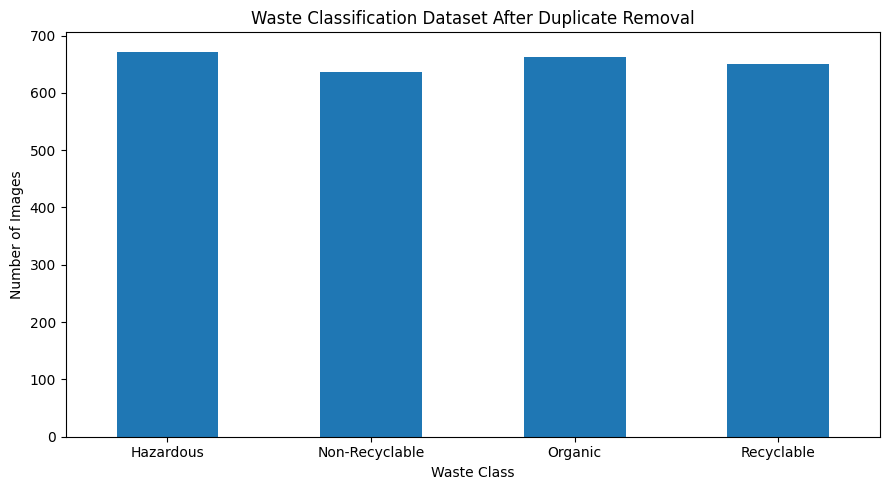

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member2_final_class_distribution.png


In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

class_counts.plot(
    kind="bar"
)

plt.title(
    "Waste Classification Dataset "
    "After Duplicate Removal"
)

plt.xlabel("Waste Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()

final_class_plot = (
    EDA_DIR /
    "member2_final_class_distribution.png"
)

plt.savefig(
    final_class_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", final_class_plot)

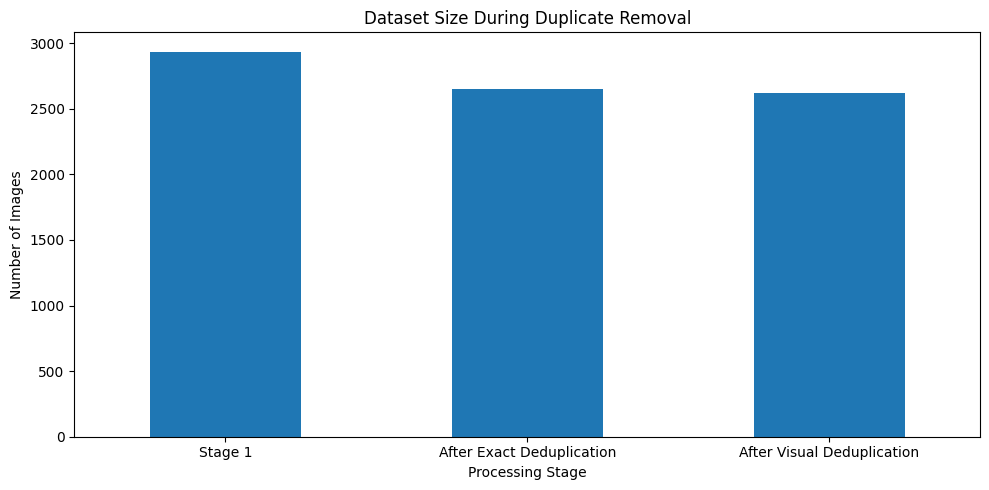

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member2_duplicate_reduction.png


In [57]:
# ============================================================
# BEFORE vs AFTER DUPLICATE REMOVAL
# ============================================================

before_after = pd.Series(
    {
        "Stage 1": 2935,
        "After Exact Deduplication": 2652,
        "After Visual Deduplication": 2622
    }
)

plt.figure(figsize=(10, 5))

before_after.plot(
    kind="bar"
)

plt.title(
    "Dataset Size During Duplicate Removal"
)

plt.xlabel("Processing Stage")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()

duplicate_reduction_plot = (
    EDA_DIR /
    "member2_duplicate_reduction.png"
)

plt.savefig(
    duplicate_reduction_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    duplicate_reduction_plot
)

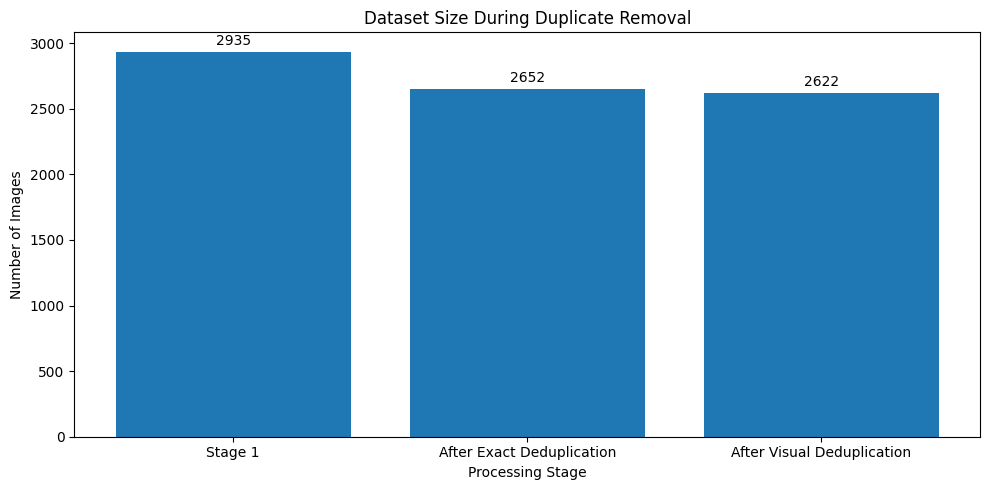

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member2_duplicate_reduction.png


In [60]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    before_after.index,
    before_after.values
)

plt.title(
    "Dataset Size During Duplicate Removal"
)

plt.xlabel("Processing Stage")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

# Add values above bars
for bar, value in zip(bars, before_after.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

final_duplicate_plot = (
    EDA_DIR /
    "member2_duplicate_reduction.png"
)

plt.savefig(
    final_duplicate_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", final_duplicate_plot)

In [61]:
# ============================================================
# FINAL MEMBER 2 DATASET VERIFICATION
# ============================================================

FINAL_STAGE2 = (
    PROJECT /
    "data" /
    "processed" /
    "stage2_visual_deduplicated"
)

final_files = [
    p for p in FINAL_STAGE2.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("=" * 70)
print("FINAL MEMBER 2 DATASET VERIFICATION")
print("=" * 70)

print("Total images:", len(final_files))
print("Expected images: 2622")
print("Count correct:", len(final_files) == 2622)

print("\nClass distribution:")

final_class_counts = {}

for class_dir in sorted(FINAL_STAGE2.iterdir()):

    if class_dir.is_dir():

        count = sum(
            1
            for p in class_dir.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        final_class_counts[class_dir.name] = count

        print(f"{class_dir.name}: {count}")

print(
    "\nClass total:",
    sum(final_class_counts.values())
)

if len(final_files) == 2622:
    print("\n✓ FINAL IMAGE COUNT VERIFIED")
else:
    print("\n⚠️ IMAGE COUNT DOES NOT MATCH 2622")

FINAL MEMBER 2 DATASET VERIFICATION
Total images: 2622
Expected images: 2622
Count correct: True

Class distribution:
Hazardous: 672
Non-Recyclable: 637
Organic: 663
Recyclable: 650

Class total: 2622

✓ FINAL IMAGE COUNT VERIFIED


In [62]:
# ============================================================
# MEMBER 2 FINAL DATASET MANIFEST
# ============================================================

manifest_records = []

for file_path in final_files:

    relative_path = file_path.relative_to(FINAL_STAGE2)

    manifest_records.append({
        "file": str(relative_path),
        "class": relative_path.parts[0],
        "extension": file_path.suffix.lower()
    })

member2_final_manifest = pd.DataFrame(
    manifest_records
)

manifest_path = (
    OUTPUT_DIR /
    "member2_stage2_final_manifest.csv"
)

member2_final_manifest.to_csv(
    manifest_path,
    index=False
)

print("=" * 70)
print("FINAL MANIFEST CREATED")
print("=" * 70)

print("Rows:", len(member2_final_manifest))
print("Saved:", manifest_path)

display(member2_final_manifest.head(10))

FINAL MANIFEST CREATED
Rows: 2622
Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member2_stage2_final_manifest.csv


,file,class,extension
0,Recyclable/Recyclable/cans_all_type/-can-massa...,Recyclable,.jpg
1,Recyclable/Recyclable/cans_all_type/-can-mock-...,Recyclable,.jpg
2,Recyclable/Recyclable/cans_all_type/-drops-moc...,Recyclable,.jpg
3,Recyclable/Recyclable/cans_all_type/-metallic-...,Recyclable,.jpg
4,Recyclable/Recyclable/cans_all_type/-of-soda-d...,Recyclable,.jpg
5,Recyclable/Recyclable/cans_all_type/0-Intro-ca...,Recyclable,.jpg
6,Recyclable/Recyclable/cans_all_type/012893089_...,Recyclable,.png
7,Recyclable/Recyclable/cans_all_type/01_ref_aer...,Recyclable,.jpg
8,Recyclable/Recyclable/cans_all_type/02-zero-wa...,Recyclable,.jpg
9,Recyclable/Recyclable/cans_all_type/1000_F_562...,Recyclable,.jpg


In [63]:
# ============================================================
# FINAL MANIFEST INTEGRITY CHECK
# ============================================================

missing_files = []

for relative_file in member2_final_manifest["file"]:

    full_path = FINAL_STAGE2 / relative_file

    if not full_path.exists():
        missing_files.append(relative_file)

print("=" * 70)
print("FINAL MANIFEST INTEGRITY CHECK")
print("=" * 70)

print("Manifest rows:", len(member2_final_manifest))
print("Missing files:", len(missing_files))

if len(missing_files) == 0:
    print()
    print("✓ ALL 2,622 MANIFEST FILES EXIST")
    print("✓ MEMBER 2 DATASET IS FULLY VERIFIED")
else:
    print()
    print("⚠️ Missing files detected:")

    for f in missing_files[:20]:
        print(f)

FINAL MANIFEST INTEGRITY CHECK
Manifest rows: 2622
Missing files: 0

✓ ALL 2,622 MANIFEST FILES EXIST
✓ MEMBER 2 DATASET IS FULLY VERIFIED


In [64]:
# ============================================================
# MEMBER 2 FINAL CLASS DISTRIBUTION
# ============================================================

class_counts = (
    member2_final_manifest["class"]
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("MEMBER 2 FINAL CLASS DISTRIBUTION")
print("=" * 70)

print(class_counts)

print()
print("Total:", class_counts.sum())

MEMBER 2 FINAL CLASS DISTRIBUTION
class
Hazardous         672
Non-Recyclable    637
Organic           663
Recyclable        650
Name: count, dtype: int64

Total: 2622


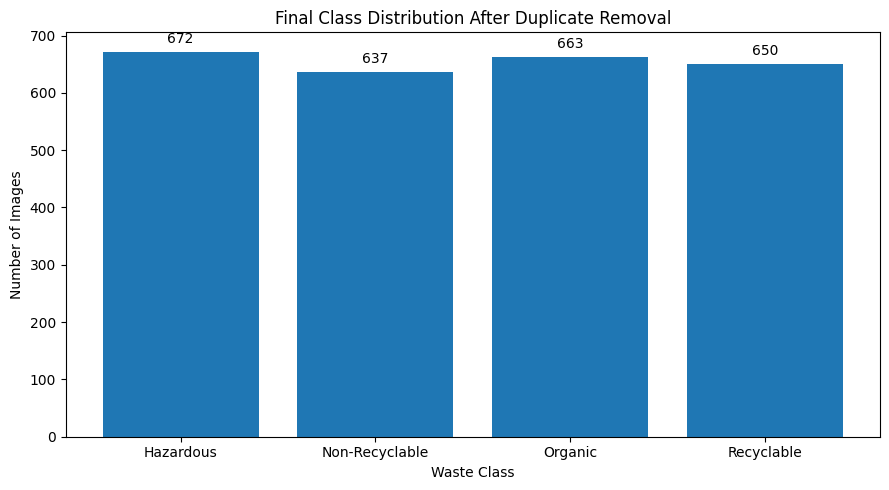


Saved:
/content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member2_final_class_distribution.png


In [65]:
# ============================================================
# SAVE FINAL CLASS DISTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

bars = plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title(
    "Final Class Distribution After Duplicate Removal"
)

plt.xlabel("Waste Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

# Display values above bars
for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

final_class_plot = (
    EDA_DIR /
    "member2_final_class_distribution.png"
)

plt.savefig(
    final_class_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(final_class_plot)

In [66]:
# ============================================================
# FINAL MEMBER 2 SUMMARY
# ============================================================

print("=" * 70)
print("MEMBER 2 PREPROCESSING SUMMARY")
print("=" * 70)

print("Stage 1 input:", 2935)
print("After exact deduplication:", 2652)
print("After visual deduplication:", 2622)

print()
print("Exact same-class exclusions:", 283)
print("Visual same-class exclusions:", 30)
print("Cross-class images flagged:", 4)

print()
print("Final dataset:", len(member2_final_manifest))
print("Missing files:", len(missing_files))

print()
print("Output dataset:")
print(FINAL_STAGE2)

print()
print("Final manifest:")
print(manifest_path)

print()
print("✓ MEMBER 2 PREPROCESSING COMPLETE")

MEMBER 2 PREPROCESSING SUMMARY
Stage 1 input: 2935
After exact deduplication: 2652
After visual deduplication: 2622

Exact same-class exclusions: 283
Visual same-class exclusions: 30
Cross-class images flagged: 4

Final dataset: 2622
Missing files: 0

Output dataset:
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_visual_deduplicated

Final manifest:
/content/drive/MyDrive/Waste_Classification/results/outputs/member2_stage2_final_manifest.csv

✓ MEMBER 2 PREPROCESSING COMPLETE


# Member 2 – Duplicate Detection Final Summary

## Input
Stage 1 dataset: 2,935 images.

## Exact Duplicate Detection
SHA-256 hashing was used to identify exact duplicate images.

- Exact duplicate groups: 286
- Same-class duplicate groups: 281
- Cross-class duplicate groups: 5
- Same-class duplicate images excluded: 283
- Dataset after exact deduplication: 2,652 images

## Visual / Near-Duplicate Detection
Perceptual hashing (pHash) was used to identify visually similar candidate pairs.

- pHash candidate pairs: 43
- Already identified exact-duplicate relationships: 11
- New visual candidate pairs: 32
- Visual duplicate groups: 32
- Same-class visual exclusions: 30
- Cross-class images flagged for label review: 4

## Final Output

Final Member 2 dataset: **2,622 images**

Output:
`data/processed/stage2_visual_deduplicated`

Final manifest:
`results/outputs/member2_stage2_final_manifest.csv`

Integrity verification:
- Final images: 2,622
- Manifest rows: 2,622
- Missing files: 0

Therefore, the Member 2 preprocessing output is verified and ready for the next preprocessing stage.

In [67]:
!cd /content/drive/MyDrive/Waste_Classification && git status

Refresh index: 100% (8/8), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/IT25102140_DatasetCleaning.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/IT25102378_DuplicateDetection.ipynb
	results/outputs/IT25102140_completion_record.json

no changes added to commit (use "git add" and/or "git commit -a")


In [68]:
%cd /content/drive/MyDrive/Waste_Classification

!git add notebooks/IT25102378_DuplicateDetection.ipynb

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [69]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    .gitignore
	deleted:    README.md
	deleted:    audit_reports/member1_image_audit.csv
	deleted:    audit_reports/member1_image_warnings.csv
	deleted:    notebooks/IT25102140_DatasetCleaning.ipynb
	new file:   notebooks/IT25102378_DuplicateDetection.ipynb
	deleted:    results/eda_visualizations/member1_class_distribution.png
	deleted:    results/eda_visualizations/member1_dimensions.png
	deleted:    results/outputs/member1_stage1_manifest.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	audit_reports/
	notebooks/IT25102140_DatasetCleaning.ipynb
	results/



In [70]:
%cd /content/drive/MyDrive/Waste_Classification

!git restore --staged .

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [71]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    .gitignore
	deleted:    README.md
	deleted:    audit_reports/member1_image_audit.csv
	deleted:    audit_reports/member1_image_warnings.csv
	deleted:    notebooks/IT25102140_DatasetCleaning.ipynb
	deleted:    results/eda_visualizations/member1_class_distribution.png
	deleted:    results/eda_visualizations/member1_dimensions.png
	deleted:    results/outputs/member1_stage1_manifest.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/



In [72]:
%cd /content/drive/MyDrive/Waste_Classification

!git reset

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
Unstaged changes after reset:
M	notebooks/IT25102140_DatasetCleaning.ipynb


In [73]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    .gitignore
	deleted:    README.md
	deleted:    audit_reports/member1_image_audit.csv
	deleted:    audit_reports/member1_image_warnings.csv
	deleted:    notebooks/IT25102140_DatasetCleaning.ipynb
	deleted:    results/eda_visualizations/member1_class_distribution.png
	deleted:    results/eda_visualizations/member1_dimensions.png
	deleted:    results/outputs/member1_stage1_manifest.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/



In [74]:
%cd /content/drive/MyDrive/Waste_Classification

!echo "=== REPOSITORY ==="
!git rev-parse --show-toplevel

!echo ""
!echo "=== CURRENT BRANCH ==="
!git branch --show-current

!echo ""
!echo "=== STAGED CHANGES ==="
!git diff --cached --name-status

!echo ""
!echo "=== TRACKED FILES ==="
!git ls-files

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
=== REPOSITORY ===
/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

=== CURRENT BRANCH ===
main

=== STAGED CHANGES ===
D	.gitignore
D	README.md
D	audit_reports/member1_image_audit.csv
D	audit_reports/member1_image_warnings.csv
D	notebooks/IT25102140_DatasetCleaning.ipynb
D	results/eda_visualizations/member1_class_distribution.png
D	results/eda_visualizations/member1_dimensions.png
D	results/outputs/member1_stage1_manifest.csv

=== TRACKED FILES ===


In [75]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git restore --staged -- .

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [76]:
!git status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/IT25102140_DatasetCleaning.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/IT25102378_DuplicateDetection.ipynb
	results/outputs/IT25102140_completion_record.json

no changes added to commit (use "git add" and/or "git commit -a")


In [78]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git status --short --untracked-files=all

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
D  .gitignore
D  README.md
D  audit_reports/member1_image_audit.csv
D  audit_reports/member1_image_warnings.csv
D  notebooks/IT25102140_DatasetCleaning.ipynb
D  results/eda_visualizations/member1_class_distribution.png
D  results/eda_visualizations/member1_dimensions.png
D  results/outputs/member1_stage1_manifest.csv
?? .gitignore
?? README.md
?? audit_reports/member1_image_audit.csv
?? audit_reports/member1_image_warnings.csv
?? notebooks/IT25102140_DatasetCleaning.ipynb
?? notebooks/IT25102378_DuplicateDetection.ipynb
?? results/eda_visualizations/member1_class_distribution.png
?? results/eda_visualizations/member1_dimensions.png
?? results/outputs/IT25102140_completion_record.json
?? results/outputs/member1_stage1_manifest.csv


In [79]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git read-tree HEAD

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [80]:
!git status --short --untracked-files=all

 M notebooks/IT25102140_DatasetCleaning.ipynb
?? notebooks/IT25102378_DuplicateDetection.ipynb
?? results/outputs/IT25102140_completion_record.json


In [81]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git add notebooks/IT25102378_DuplicateDetection.ipynb

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [82]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    .gitignore
	deleted:    README.md
	deleted:    audit_reports/member1_image_audit.csv
	deleted:    audit_reports/member1_image_warnings.csv
	deleted:    notebooks/IT25102140_DatasetCleaning.ipynb
	new file:   notebooks/IT25102378_DuplicateDetection.ipynb
	deleted:    results/eda_visualizations/member1_class_distribution.png
	deleted:    results/eda_visualizations/member1_dimensions.png
	deleted:    results/outputs/member1_stage1_manifest.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	audit_reports/
	notebooks/IT25102140_DatasetCleaning.ipynb
	results/



In [83]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git reset HEAD

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
Unstaged changes after reset:
M	notebooks/IT25102140_DatasetCleaning.ipynb


In [84]:
!git read-tree HEAD

In [85]:
!git status --short --untracked-files=all

 M notebooks/IT25102140_DatasetCleaning.ipynb
?? notebooks/IT25102378_DuplicateDetection.ipynb
?? results/outputs/IT25102140_completion_record.json


In [86]:
!git ls-files

In [87]:
!git status --short --untracked-files=all

D  .gitignore
D  README.md
D  audit_reports/member1_image_audit.csv
D  audit_reports/member1_image_warnings.csv
D  notebooks/IT25102140_DatasetCleaning.ipynb
D  results/eda_visualizations/member1_class_distribution.png
D  results/eda_visualizations/member1_dimensions.png
D  results/outputs/member1_stage1_manifest.csv
?? .gitignore
?? README.md
?? audit_reports/member1_image_audit.csv
?? audit_reports/member1_image_warnings.csv
?? notebooks/IT25102140_DatasetCleaning.ipynb
?? notebooks/IT25102378_DuplicateDetection.ipynb
?? results/eda_visualizations/member1_class_distribution.png
?? results/eda_visualizations/member1_dimensions.png
?? results/outputs/IT25102140_completion_record.json
?? results/outputs/member1_stage1_manifest.csv


In [88]:
!git ls-files

In [89]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!echo "=== HEAD ==="
!git rev-parse HEAD

!echo ""
!echo "=== FILES IN HEAD ==="
!git ls-tree -r HEAD --name-only

!echo ""
!echo "=== GIT INDEX ==="
!git rev-parse --git-path index
!ls -l .git/index

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
=== HEAD ===
edb70a1fb632051f5df4fb610285b53387951a01

=== FILES IN HEAD ===
.gitignore
README.md
audit_reports/member1_image_audit.csv
audit_reports/member1_image_warnings.csv
notebooks/IT25102140_DatasetCleaning.ipynb
results/eda_visualizations/member1_class_distribution.png
results/eda_visualizations/member1_dimensions.png
results/outputs/member1_stage1_manifest.csv

=== GIT INDEX ===
.git/index
ls: cannot access '.git/index': No such file or directory


In [90]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git reset --mixed HEAD

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
Unstaged changes after reset:
M	notebooks/IT25102140_DatasetCleaning.ipynb


In [91]:
!ls -l .git/index

-rw------- 1 root root 848 Aug 23 12:33 .git/index


In [92]:
!git status --short --untracked-files=all

D  .gitignore
D  README.md
D  audit_reports/member1_image_audit.csv
D  audit_reports/member1_image_warnings.csv
D  notebooks/IT25102140_DatasetCleaning.ipynb
D  results/eda_visualizations/member1_class_distribution.png
D  results/eda_visualizations/member1_dimensions.png
D  results/outputs/member1_stage1_manifest.csv
?? .gitignore
?? README.md
?? audit_reports/member1_image_audit.csv
?? audit_reports/member1_image_warnings.csv
?? notebooks/IT25102140_DatasetCleaning.ipynb
?? notebooks/IT25102378_DuplicateDetection.ipynb
?? results/eda_visualizations/member1_class_distribution.png
?? results/eda_visualizations/member1_dimensions.png
?? results/outputs/IT25102140_completion_record.json
?? results/outputs/member1_stage1_manifest.csv


In [93]:
!git ls-files

In [94]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git read-tree --reset HEAD

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [95]:
!git status --short --untracked-files=all

 M notebooks/IT25102140_DatasetCleaning.ipynb
?? notebooks/IT25102378_DuplicateDetection.ipynb
?? results/outputs/IT25102140_completion_record.json


In [96]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git add notebooks/IT25102378_DuplicateDetection.ipynb

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [97]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    .gitignore
	deleted:    README.md
	deleted:    audit_reports/member1_image_audit.csv
	deleted:    audit_reports/member1_image_warnings.csv
	deleted:    notebooks/IT25102140_DatasetCleaning.ipynb
	deleted:    results/eda_visualizations/member1_class_distribution.png
	deleted:    results/eda_visualizations/member1_dimensions.png
	deleted:    results/outputs/member1_stage1_manifest.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/



In [98]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

!git remote -v

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
origin	https://github.com/IT25102140/waste-classification-aiml.git (fetch)
origin	https://github.com/IT25102140/waste-classification-aiml.git (push)


In [99]:
!cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification && git remote get-url origin

https://github.com/IT25102140/waste-classification-aiml.git


In [100]:
%cd /content

!rm -rf Waste_Classification_Git

!git clone "PASTE_THE_EXACT_URL_HERE" Waste_Classification_Git

/content
fatal: repository 'PASTE_THE_EXACT_URL_HERE' does not exist


In [101]:
%cd /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification

REPO_URL = !git remote get-url origin
REPO_URL = REPO_URL[0]

print("Repository URL:")
print(REPO_URL)

/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification
Repository URL:
https://github.com/IT25102140/waste-classification-aiml.git


In [102]:
%cd /content

!rm -rf Waste_Classification_Git

!git clone "$REPO_URL" Waste_Classification_Git

/content
Cloning into 'Waste_Classification_Git'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 2), reused 18 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 332.80 KiB | 22.19 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [103]:
%cd /content/Waste_Classification_Git

!git status

/content/Waste_Classification_Git
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [104]:
!find . -maxdepth 2 -type f | sort

./audit_reports/member1_image_audit.csv
./audit_reports/member1_image_warnings.csv
./.git/config
./.git/description
./.git/HEAD
./.gitignore
./.git/index
./.git/packed-refs
./notebooks/IT25102140_DatasetCleaning.ipynb
./README.md


In [105]:
%cd /content/Waste_Classification_Git
!git status

/content/Waste_Classification_Git
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [106]:
import shutil
from pathlib import Path

DRIVE_PROJECT = Path(
    "/content/drive/.shortcut-targets-by-id/"
    "1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/"
    "Waste_Classification"
)

LOCAL_PROJECT = Path("/content/Waste_Classification_Git")

source = DRIVE_PROJECT / "notebooks" / "IT25102378_DuplicateDetection.ipynb"
destination = LOCAL_PROJECT / "notebooks" / "IT25102378_DuplicateDetection.ipynb"

shutil.copy2(source, destination)

print("✓ Copied Member 2 notebook")

✓ Copied Member 2 notebook


In [107]:
member2_files = [
    "results/outputs/member2_perceptual_hashes.csv",
    "results/outputs/member2_new_visual_duplicate_candidates.csv",
    "results/outputs/member2_same_class_exact_duplicate_exclusions.csv",
    "results/outputs/member2_final_visual_duplicate_review.csv",
    "results/outputs/member2_stage2_final_manifest.csv",
]

for relative_path in member2_files:
    source = DRIVE_PROJECT / relative_path
    destination = LOCAL_PROJECT / relative_path

    destination.parent.mkdir(parents=True, exist_ok=True)

    if source.exists():
        shutil.copy2(source, destination)
        print("✓", relative_path)
    else:
        print("✗ MISSING:", relative_path)

✗ MISSING: results/outputs/member2_perceptual_hashes.csv
✗ MISSING: results/outputs/member2_new_visual_duplicate_candidates.csv
✗ MISSING: results/outputs/member2_same_class_exact_duplicate_exclusions.csv
✗ MISSING: results/outputs/member2_final_visual_duplicate_review.csv
✗ MISSING: results/outputs/member2_stage2_final_manifest.csv


In [108]:
import os

search_root = "/content/drive"

target_names = {
    "member2_perceptual_hashes.csv",
    "member2_new_visual_duplicate_candidates.csv",
    "member2_same_class_exact_duplicate_exclusions.csv",
    "member2_final_visual_duplicate_review.csv",
    "member2_stage2_final_manifest.csv",
}

print("=" * 70)
print("SEARCHING FOR MEMBER 2 OUTPUTS")
print("=" * 70)

found = {}

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file in target_names:
            full_path = os.path.join(root, file)
            found[file] = full_path

for name in sorted(target_names):
    if name in found:
        print("✓", name)
        print("  ", found[name])
    else:
        print("✗ NOT FOUND:", name)

print("=" * 70)
print("Found:", len(found), "/", len(target_names))

SEARCHING FOR MEMBER 2 OUTPUTS
✗ NOT FOUND: member2_final_visual_duplicate_review.csv
✗ NOT FOUND: member2_new_visual_duplicate_candidates.csv
✗ NOT FOUND: member2_perceptual_hashes.csv
✗ NOT FOUND: member2_same_class_exact_duplicate_exclusions.csv
✗ NOT FOUND: member2_stage2_final_manifest.csv
Found: 0 / 5


In [109]:
import os

print("=" * 70)
print("SEARCHING FOR MEMBER 2 FINAL DATASET")
print("=" * 70)

for root, dirs, files in os.walk("/content/drive"):
    if os.path.basename(root) == "stage2_visual_deduplicated":
        print("FOUND:")
        print(root)

SEARCHING FOR MEMBER 2 FINAL DATASET
FOUND:
/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/processed/stage2_visual_deduplicated


In [110]:
print("=" * 70)
print("SEARCHING FOR MEMBER 2 NOTEBOOK")
print("=" * 70)

for root, dirs, files in os.walk("/content/drive"):
    for file in files:
        if file == "IT25102378_DuplicateDetection.ipynb":
            print(os.path.join(root, file))

SEARCHING FOR MEMBER 2 NOTEBOOK
/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/notebooks/IT25102378_DuplicateDetection.ipynb


In [111]:
print("=" * 70)
print("SEARCHING FOR MEMBER 2 EDA")
print("=" * 70)

for root, dirs, files in os.walk("/content/drive"):
    for file in files:
        if file.startswith("member2_"):
            print(os.path.join(root, file))

SEARCHING FOR MEMBER 2 EDA


In [112]:
from pathlib import Path

FINAL_STAGE2 = Path(
    "/content/drive/.shortcut-targets-by-id/"
    "1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/"
    "Waste_Classification/data/processed/"
    "stage2_visual_deduplicated"
)

image_extensions = {
    ".jpg", ".jpeg", ".png", ".gif",
    ".bmp", ".webp", ".tif", ".tiff"
}

final_files = [
    p for p in FINAL_STAGE2.rglob("*")
    if p.is_file()
    and p.suffix.lower() in image_extensions
]

print("=" * 70)
print("MEMBER 2 DATASET CHECK")
print("=" * 70)

print("Dataset:", FINAL_STAGE2)
print("Images:", len(final_files))
print("Expected: 2622")
print("Correct:", len(final_files) == 2622)

MEMBER 2 DATASET CHECK
Dataset: /content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification/data/processed/stage2_visual_deduplicated
Images: 2622
Expected: 2622
Correct: True
